## Load Dataset

In [2]:
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
import warnings

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

In [8]:
df = pd.read_csv(r"C:\Users\shiri\OneDrive\Documents\Python\ml-projects\exchange-rates-forecasting\data\raw\Exchange_rate_report.csv")

## Basic Exploration

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6323 entries, 0 to 6322
Data columns (total 8 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Date                                            6323 non-null   object 
 1   Australian dollar   (AUD)                       6040 non-null   float64
 2   Euro   (EUR)                                    6230 non-null   float64
 3   Indian rupee   (INR)                            5804 non-null   float64
 4   Japanese yen   (JPY)                            5980 non-null   float64
 5   U.A.E. dirham   (AED)                           5939 non-null   float64
 6   U.K. pound   (GBP)                              6205 non-null   float64
 7   U.S. dollar   (USD)                             6323 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 395.3+ KB


In [11]:
df.shape

(6323, 8)

In [13]:
df.columns

Index(['Date', 'Australian dollar   (AUD)                     ',
       'Euro   (EUR)                     ',
       'Indian rupee   (INR)                     ',
       'Japanese yen   (JPY)                     ',
       'U.A.E. dirham   (AED)                     ',
       'U.K. pound   (GBP)                     ',
       'U.S. dollar   (USD)                     '],
      dtype='object')

In [14]:
df.nunique()

Date                                              6323
Australian dollar   (AUD)                         3259
Euro   (EUR)                                      3659
Indian rupee   (INR)                              3697
Japanese yen   (JPY)                              2914
U.A.E. dirham   (AED)                                2
U.K. pound   (GBP)                                4396
U.S. dollar   (USD)                                  1
dtype: int64

In [23]:
df.describe()

,Australian dollar (AUD),Euro (EUR),Indian rupee (INR),Japanese yen (JPY),U.A.E. dirham (AED),U.K. pound (GBP),U.S. dollar (USD)
count,6323.000000,6323.000000,6323.000000,6323.000000,6323.000000,6323.000000,6323.0
mean,0.761787,1.189174,57.657420,110.815001,3.672500,1.529957,1.0
std,0.139190,0.157789,13.543476,16.620085,0.000031,0.223648,0.0
min,0.483300,0.825200,39.270000,75.860000,3.672500,1.065400,1.0
25%,0.673350,1.088700,45.830000,103.275000,3.672500,1.323800,1.0
50%,0.746100,1.181000,52.230000,109.960000,3.672500,1.525300,1.0
75%,0.845350,1.308000,68.643650,118.900000,3.672500,1.646400,1.0
max,1.105500,1.599000,85.088000,161.640000,3.675000,2.102000,1.0


## Data Cleaning

### Duplicates

In [18]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Missing values

In [17]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values

Australian dollar   (AUD)                         283
Euro   (EUR)                                       93
Indian rupee   (INR)                              519
Japanese yen   (JPY)                              343
U.A.E. dirham   (AED)                             384
U.K. pound   (GBP)                                118
dtype: int64

In [19]:
# Handle missing values
# Forward-fill, then backward-fill for any remaining NaNs
df = df.ffill().bfill()

### Data Type Corrections

In [21]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

### Clean names

In [24]:
# Clean column names: lowercase, snake_case, remove special characters
df = df.clean_names(case_type='snake')

### Outliers

In [28]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

In [29]:
for col in df.columns:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

australian_dollar_aud_: 2 outliers
euro_eur_: 0 outliers
indian_rupee_inr_: 0 outliers
japanese_yen_jpy_: 657 outliers
u_a_e_dirham_aed_: 1 outliers
u_k_pound_gbp_: 0 outliers
u_s_dollar_usd_: 0 outliers


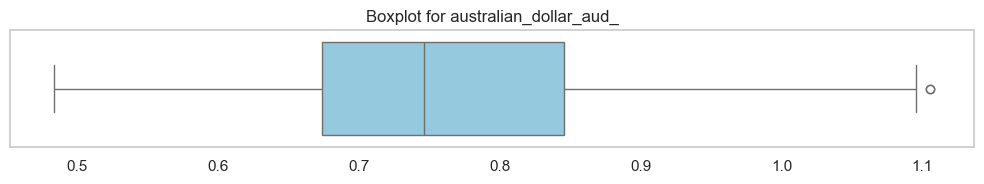

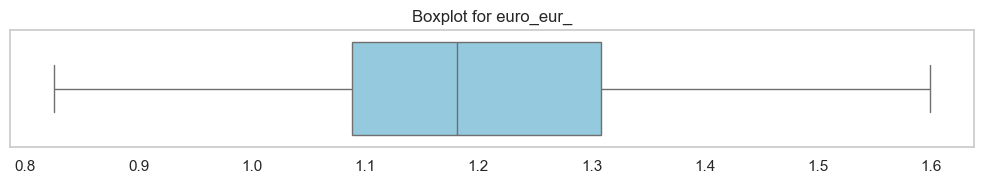

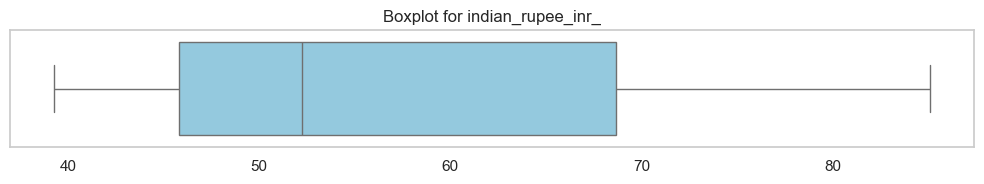

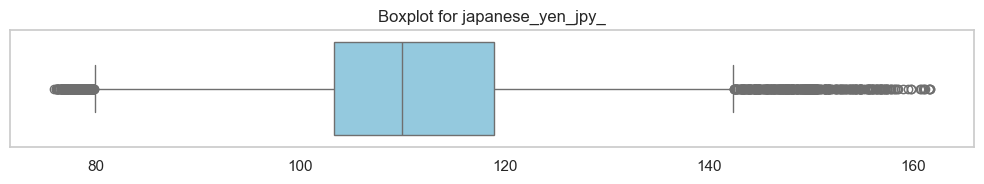

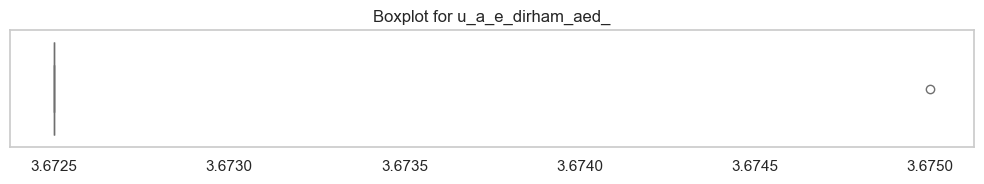

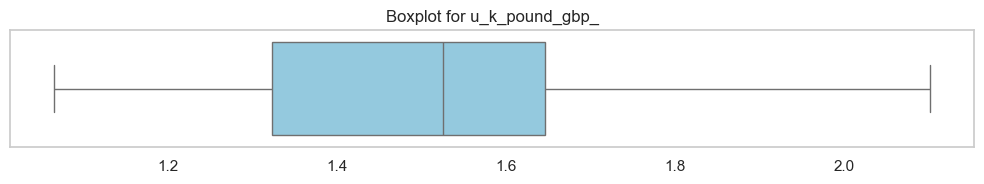

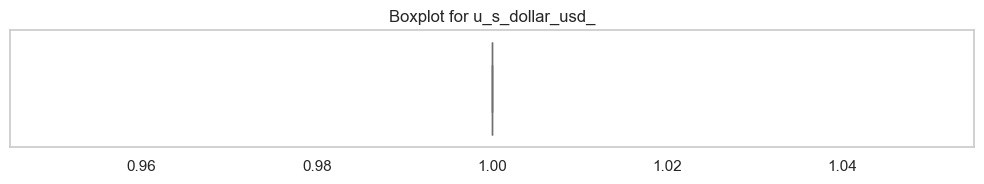

In [33]:
# Set global style
sns.set(style="whitegrid")

# Plot boxplots for all numeric columns
def plot_all_boxplots(df):
    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'Boxplot for {col}', fontsize=12)
        plt.xlabel('')
        plt.grid(False)
        plt.tight_layout()
        plt.show()

# Call the function
plot_all_boxplots(df)

The Japanese Yen (JPY) values have a naturally higher magnitude range (around 75 to 160+), which is much larger than other currency values. Due to this larger scale and slight skewness in the data distribution, many values fall just outside the typical IQR whisker bounds (1.5 × IQR). This causes the boxplot to mark them as outliers even though they are part of the natural variability of the data and not necessarily erroneous or extreme values. Therefore, these ‘outliers’ should be interpreted cautiously and not automatically removed.


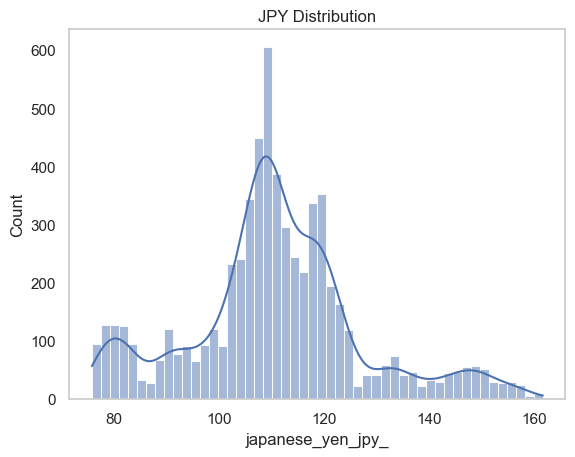

In [35]:
sns.histplot(df['japanese_yen_jpy_'], kde=True, bins=50)
plt.title('JPY Distribution')
plt.grid(False)
plt.show()

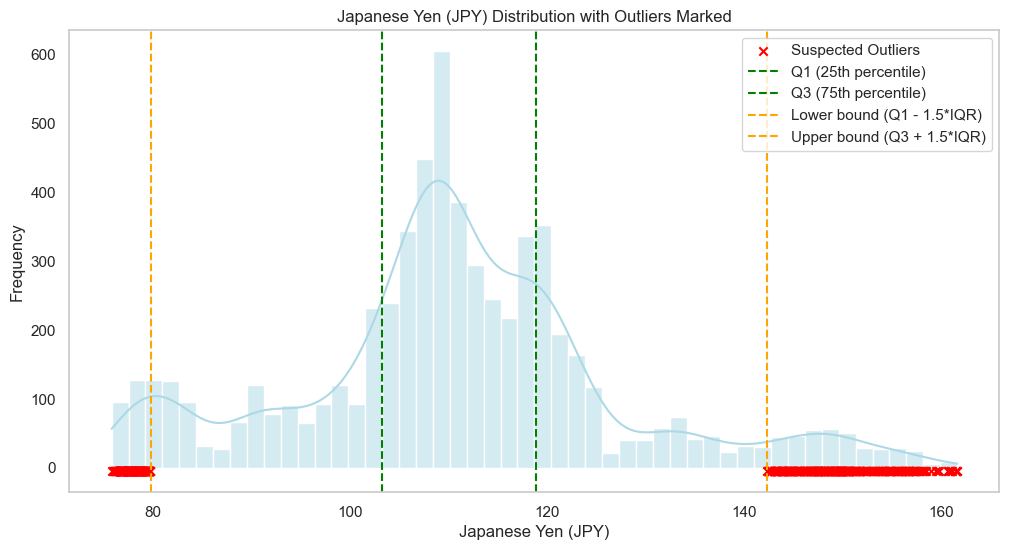

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate quartiles and IQR
Q1 = df['japanese_yen_jpy_'].quantile(0.25)
Q3 = df['japanese_yen_jpy_'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers based on IQR
outliers = df[(df['japanese_yen_jpy_'] < lower_bound) | (df['japanese_yen_jpy_'] > upper_bound)]['japanese_yen_jpy_']

plt.figure(figsize=(12,6))

# Histogram + KDE for full data
sns.histplot(df['japanese_yen_jpy_'], bins=50, kde=True, color='lightblue')

# Scatter plot to mark outliers on x-axis at some low y-level (to show visually)
plt.scatter(outliers, [-5]*len(outliers), color='red', marker='x', label='Suspected Outliers')

# Add vertical lines for Q1, Q3, lower bound, upper bound
plt.axvline(Q1, color='green', linestyle='--', label='Q1 (25th percentile)')
plt.axvline(Q3, color='green', linestyle='--', label='Q3 (75th percentile)')
plt.axvline(lower_bound, color='orange', linestyle='--', label='Lower bound (Q1 - 1.5*IQR)')
plt.axvline(upper_bound, color='orange', linestyle='--', label='Upper bound (Q3 + 1.5*IQR)')

plt.title('Japanese Yen (JPY) Distribution with Outliers Marked')
plt.xlabel('Japanese Yen (JPY)')
plt.ylabel('Frequency')
plt.grid(False)
plt.legend()
plt.show()
